# CREDIT CARD FRAUD DETECTION USING NEURAL NETWORK

In [1]:
#importing libraries
import pandas as pd

In [2]:
# loading the dataset
import pandas as pd

df = pd.read_csv(r"C:\Users\Ayush\OneDrive\Desktop\ANN capstone\fraudTest.csv")

In [3]:
df.shape

(555719, 23)

In [4]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [5]:
df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='str')

In [6]:
df['state'].unique()

<ArrowStringArray>
['SC', 'UT', 'NY', 'FL', 'MI', 'CA', 'SD', 'PA', 'TX', 'KY', 'WY', 'AL', 'LA',
 'GA', 'CO', 'OH', 'WI', 'VT', 'AR', 'NJ', 'IA', 'MD', 'MS', 'KS', 'IL', 'MO',
 'ME', 'TN', 'DC', 'AZ', 'MT', 'MN', 'OK', 'WA', 'WV', 'NM', 'MA', 'NE', 'VA',
 'ID', 'OR', 'IN', 'NC', 'NH', 'ND', 'CT', 'NV', 'HI', 'RI', 'AK']
Length: 50, dtype: str

In [7]:
# 1. DELETING UNWANTED COLUMNS
df.drop(columns = ['Unnamed: 0', 'trans_date_trans_time', 'cc_num',
                   'merchant', 'first', 'last','street', 'city', 'zip', 'lat', 'long', 'dob', 'trans_num', 'unix_time'],
        inplace = True)

In [8]:
df.drop(columns = ['merch_lat', 'merch_long'], inplace = True)

In [9]:
df.head()

,category,amt,gender,state,city_pop,job,is_fraud
0,personal_care,2.86,M,SC,333497,Mechanical engineer,0
1,personal_care,29.84,F,UT,302,"Sales professional, IT",0
2,health_fitness,41.28,F,NY,34496,"Librarian, public",0
3,misc_pos,60.05,M,FL,54767,Set designer,0
4,travel,3.19,M,MI,1126,Furniture designer,0


In [10]:
# 2. Checking for null values
df.isna().sum()

category    0
amt         0
gender      0
state       0
city_pop    0
job         0
is_fraud    0
dtype: int64

In [11]:
df.dropna(inplace = True)

In [12]:
df.isna().sum()

category    0
amt         0
gender      0
state       0
city_pop    0
job         0
is_fraud    0
dtype: int64

In [13]:
# 3. CATEGORICAL TO NUMERICAL ENCODING
df['category'].unique()

<ArrowStringArray>
[ 'personal_care', 'health_fitness',       'misc_pos',         'travel',
      'kids_pets',   'shopping_pos',    'food_dining',           'home',
  'entertainment',   'shopping_net',       'misc_net',    'grocery_pos',
  'gas_transport',    'grocery_net']
Length: 14, dtype: str

In [14]:
category_df = (pd.get_dummies(df['category'])).astype('int')

In [15]:
category_df.head()

,entertainment,food_dining,gas_transport,grocery_net,grocery_pos,health_fitness,home,kids_pets,misc_net,misc_pos,personal_care,shopping_net,shopping_pos,travel
0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
1,0,0,0,0,0,0,0,0,0,0,1,0,0,0
2,0,0,0,0,0,1,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,1


In [16]:
df.drop(columns = ['category'], inplace = True)

In [17]:
df.head(3)

,amt,gender,state,city_pop,job,is_fraud
0,2.86,M,SC,333497,Mechanical engineer,0
1,29.84,F,UT,302,"Sales professional, IT",0
2,41.28,F,NY,34496,"Librarian, public",0


In [18]:
df = pd.concat([df, category_df], axis = 1)

In [19]:
df.head(3)

,amt,gender,state,city_pop,job,is_fraud,entertainment,food_dining,gas_transport,grocery_net,grocery_pos,health_fitness,home,kids_pets,misc_net,misc_pos,personal_care,shopping_net,shopping_pos,travel
0,2.86,M,SC,333497,Mechanical engineer,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
1,29.84,F,UT,302,"Sales professional, IT",0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
2,41.28,F,NY,34496,"Librarian, public",0,0,0,0,0,0,1,0,0,0,0,0,0,0,0


In [20]:
df['gender'].unique()

<ArrowStringArray>
['M', 'F']
Length: 2, dtype: str

In [21]:
df['gender'] = df['gender'].map({'F': 1, 'M': 0})

In [22]:
df['gender'].unique()

array([0, 1])

In [23]:
df['state'].unique()

<ArrowStringArray>
['SC', 'UT', 'NY', 'FL', 'MI', 'CA', 'SD', 'PA', 'TX', 'KY', 'WY', 'AL', 'LA',
 'GA', 'CO', 'OH', 'WI', 'VT', 'AR', 'NJ', 'IA', 'MD', 'MS', 'KS', 'IL', 'MO',
 'ME', 'TN', 'DC', 'AZ', 'MT', 'MN', 'OK', 'WA', 'WV', 'NM', 'MA', 'NE', 'VA',
 'ID', 'OR', 'IN', 'NC', 'NH', 'ND', 'CT', 'NV', 'HI', 'RI', 'AK']
Length: 50, dtype: str

In [24]:
state_df = (pd.get_dummies(df['state'])).astype('int')

In [25]:
state_df.head()

,AK,AL,AR,AZ,CA,CO,CT,DC,FL,GA,...,SD,TN,TX,UT,VA,VT,WA,WI,WV,WY
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [26]:
df.drop(columns = ['state'], inplace = True)

In [27]:
df = pd.concat([df, state_df], axis = 1)

In [28]:
df.head(3)

,amt,gender,city_pop,job,is_fraud,entertainment,food_dining,gas_transport,grocery_net,grocery_pos,...,SD,TN,TX,UT,VA,VT,WA,WI,WV,WY
0,2.86,0,333497,Mechanical engineer,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,29.84,1,302,"Sales professional, IT",0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
2,41.28,1,34496,"Librarian, public",0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [29]:
df['job'].unique().shape

(478,)

In [30]:
job_df = (pd.get_dummies(df['job'])).astype('int')

In [31]:
job_df.head()

,Academic librarian,"Accountant, chartered certified","Accountant, chartered public finance",Accounting technician,Acupuncturist,Administrator,"Administrator, arts","Administrator, charities/voluntary organisations","Administrator, education","Administrator, local government",...,Video editor,Visual merchandiser,Volunteer coordinator,Warden/ranger,Waste management officer,Water engineer,Water quality scientist,Web designer,Wellsite geologist,Writer
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [32]:
df.drop(columns = ['job'], inplace = True)

In [33]:
df = pd.concat([df, job_df], axis = 1)

In [34]:
df.shape

(555719, 546)

In [35]:
df.head(3)

,amt,gender,city_pop,is_fraud,entertainment,food_dining,gas_transport,grocery_net,grocery_pos,health_fitness,...,Video editor,Visual merchandiser,Volunteer coordinator,Warden/ranger,Waste management officer,Water engineer,Water quality scientist,Web designer,Wellsite geologist,Writer
0,2.86,0,333497,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,29.84,1,302,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,41.28,1,34496,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [36]:
# 4. Dividing the dataset into two parts
X = df.drop(columns = ['is_fraud'])
y = df['is_fraud']

In [37]:
X.shape

(555719, 545)

In [38]:
y.value_counts()

is_fraud
0    553574
1      2145
Name: count, dtype: int64

In [39]:
# 5. Balancing the dataset using SMOTE
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

# Encode categorical columns
for col in X.select_dtypes(include=['object', 'string']).columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Before SMOTE:")
print(y.value_counts())

print("\nAfter SMOTE:")
print(y_resampled.value_counts())

Before SMOTE:
is_fraud
0    553574
1      2145
Name: count, dtype: int64

After SMOTE:
is_fraud
0    553574
1    553574
Name: count, dtype: int64


In [40]:
y.value_counts()

is_fraud
0    553574
1      2145
Name: count, dtype: int64

In [41]:
X.shape

(555719, 545)

In [42]:
# 6. Data Normalization
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_resampled = pd.DataFrame(
    scaler.fit_transform(X_resampled),
    columns=X_resampled.columns
)

In [43]:
X.head()

,amt,gender,city_pop,entertainment,food_dining,gas_transport,grocery_net,grocery_pos,health_fitness,home,...,Video editor,Visual merchandiser,Volunteer coordinator,Warden/ranger,Waste management officer,Water engineer,Water quality scientist,Web designer,Wellsite geologist,Writer
0,2.86,0,333497,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,29.84,1,302,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,41.28,1,34496,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,60.05,0,54767,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,3.19,0,1126,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [44]:
# 7. Train - Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [45]:
X_train.shape, X_test.shape

((444575, 545), (111144, 545))

In [46]:
# 8. Building Artificial Neural Network
import tensorflow as tf
from tensorflow import keras

# Build ANN
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)),  # Automatically uses correct number of features
    keras.layers.Dense(300, activation='relu'),
    keras.layers.Dense(150, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=200,
    validation_data=(X_test, y_test),
    verbose=1
)

# Evaluate model
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"\nTest Accuracy: {accuracy:.4f}")
print(f"Test Loss: {loss:.4f}")

Epoch 1/10
2223/2223 ━━━━━━━━━━━━━━━━━━━━ 32s 13ms/step - accuracy: 0.9843 - loss: 81.7663 - val_accuracy: 0.9961 - val_loss: 77.2817
Epoch 2/10
2223/2223 ━━━━━━━━━━━━━━━━━━━━ 41s 14ms/step - accuracy: 0.9871 - loss: 52.2814 - val_accuracy: 0.9951 - val_loss: 16.1579
Epoch 3/10
2223/2223 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step - accuracy: 0.9865 - loss: 37.5103 - val_accuracy: 0.9961 - val_loss: 67.7550
Epoch 4/10
2223/2223 ━━━━━━━━━━━━━━━━━━━━ 38s 12ms/step - accuracy: 0.9902 - loss: 36.8228 - val_accuracy: 0.9887 - val_loss: 17.9564
Epoch 5/10
2223/2223 ━━━━━━━━━━━━━━━━━━━━ 25s 11ms/step - accuracy: 0.9890 - loss: 35.5449 - val_accuracy: 0.9961 - val_loss: 59.4683
Epoch 6/10
2223/2223 ━━━━━━━━━━━━━━━━━━━━ 40s 11ms/step - accuracy: 0.9913 - loss: 34.0640 - val_accuracy: 0.9961 - val_loss: 24.4958
Epoch 7/10
2223/2223 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - accuracy: 0.9909 - loss: 29.4137 - val_accuracy: 0.9886 - val_loss: 12.8332
Epoch 8/10
2223/2223 ━━━━━━━━━━━━━━━━━━━━ 26s 12ms/step - accu

In [47]:
# 9. Model Evaluation
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Model Accuracy : {accuracy * 100}')

3474/3474 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9961 - loss: 5.0519
Model Accuracy : 99.61401224136353


In [48]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 300)                 │         163,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 150)                 │          45,150 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │             151 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 627,305 (2.39 MB)

 Trainable params: 209,101 (816.80 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 418,204 (1.60 MB)

In [49]:
pred = model.predict(X_test)

3474/3474 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step


In [50]:
# 10. Prediction

In [51]:
binary_pred = (pred > 0.5).astype('int')

In [52]:
binary_pred

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [0]], shape=(111144, 1))

In [53]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, binary_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    110715
           1       0.00      0.00      0.00       429

    accuracy                           1.00    111144
   macro avg       0.50      0.50      0.50    111144
weighted avg       0.99      1.00      0.99    111144



C:\Users\Ayush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Ayush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Ayush\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


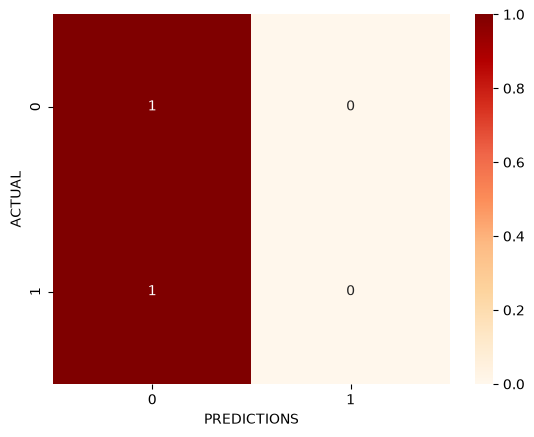

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt


cf = confusion_matrix(y_test, binary_pred, normalize = 'true')
sns.heatmap(cf, annot = True, cmap = 'OrRd');
plt.xlabel('PREDICTIONS');
plt.ylabel('ACTUAL');